In [1]:
!pip install yfinance ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=da19f31448553241999cbea0ff818968bbe6119869d981d6a6c43b277ea93aab
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download stock data
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

data.head()

/tmp/ipykernel_184/625045464.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [3]:
# Returns
data['returns'] = data['Close'].pct_change()

# Moving averages
data['ma_10'] = data['Close'].rolling(10).mean()
data['ma_50'] = data['Close'].rolling(50).mean()

# Volatility
data['volatility'] = data['returns'].rolling(10).std()

In [4]:
data['target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

In [5]:
data = data.dropna()

In [6]:
split = int(len(data) * 0.8)

train = data[:split]
test = data[split:]

In [7]:
from sklearn.ensemble import RandomForestClassifier

features = ['ma_10', 'ma_50', 'volatility']

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [8]:
test['prediction'] = model.predict(X_test)

/tmp/ipykernel_184/3864373789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = model.predict(X_test)


/tmp/ipykernel_184/2719740704.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['strategy_returns'] = test['prediction'] * test['returns']
/tmp/ipykernel_184/2719740704.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['cumulative_strategy'] = (1 + test['strategy_returns']).cumprod()
/tmp/ipykernel_184/2719740704.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

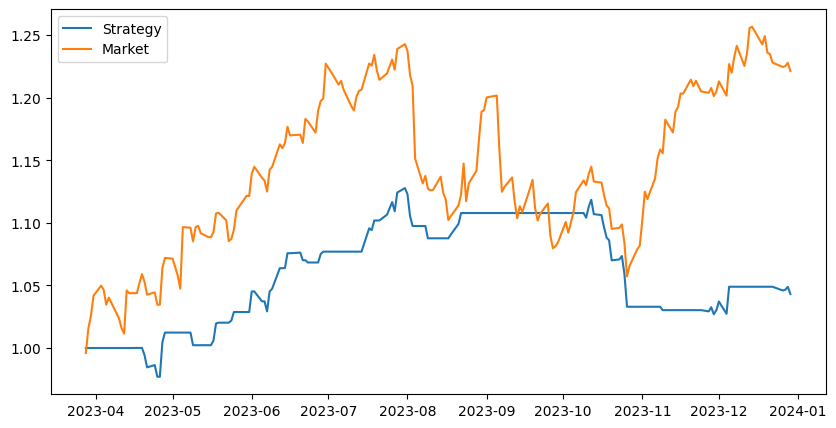

In [9]:
test['strategy_returns'] = test['prediction'] * test['returns']

# Cumulative returns
test['cumulative_strategy'] = (1 + test['strategy_returns']).cumprod()
test['cumulative_market'] = (1 + test['returns']).cumprod()

# Plot
plt.figure(figsize=(10,5))
plt.plot(test['cumulative_strategy'], label="Strategy")
plt.plot(test['cumulative_market'], label="Market")
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, test['prediction'])
print("Accuracy:", accuracy)

Accuracy: 0.4895833333333333


In [15]:
import ta
data['rsi'] = ta.momentum.RSIIndicator(data['Close'].squeeze()).rsi()

data = data.dropna()

features = ['ma_10', 'ma_50', 'volatility', 'rsi']

In [16]:
data = data.dropna()

In [17]:
!pip install xgboost

In [18]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [19]:
test['prob'] = model.predict_proba(X_test)[:,1]

In [20]:
test['position'] = 0

test.loc[test['prob'] > 0.55, 'position'] = 1   # Buy
test.loc[test['prob'] < 0.45, 'position'] = -1  # Sell

In [21]:
test['strategy_returns'] = test['position'] * test['returns']

In [22]:
test['strategy_returns'] = test['strategy_returns'].clip(-0.02, 0.02)

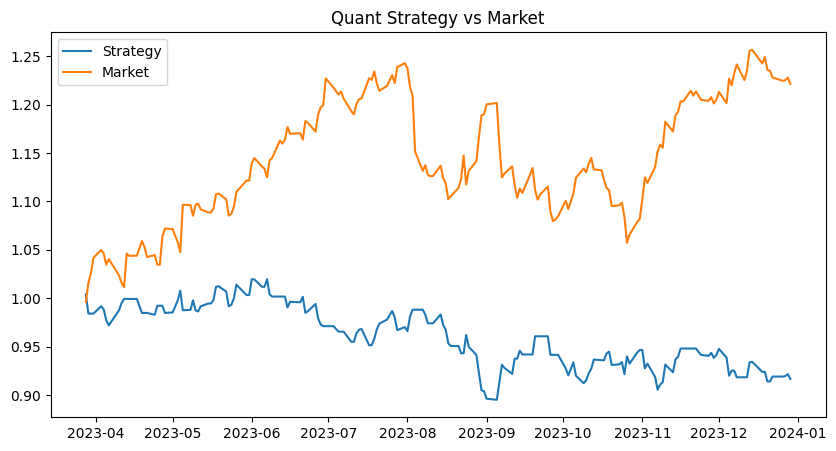

In [23]:
test['cum_strategy'] = (1 + test['strategy_returns']).cumprod()
test['cum_market'] = (1 + test['returns']).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test['cum_strategy'], label='Strategy')
plt.plot(test['cum_market'], label='Market')
plt.legend()
plt.title("Quant Strategy vs Market")
plt.show()

In [24]:
sharpe = test['strategy_returns'].mean() / test['strategy_returns'].std()
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: -0.04749036505854868


In [25]:
plt.savefig("strategy_vs_market.png")

<Figure size 640x480 with 0 Axes>

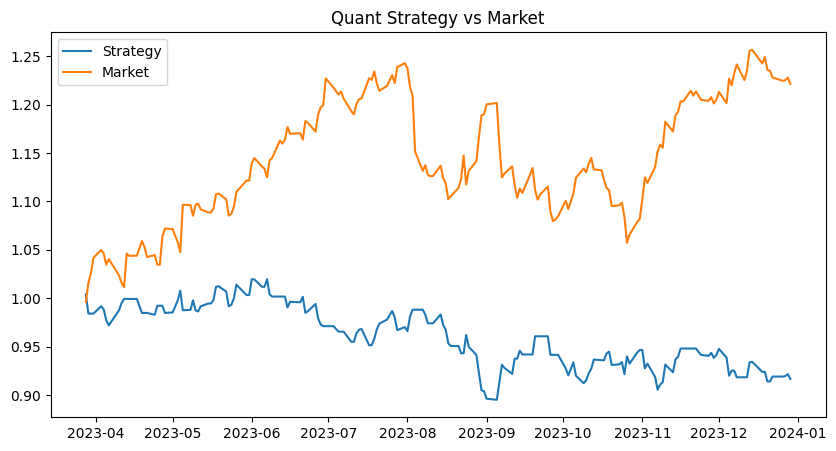

In [27]:
plt.figure(figsize=(10,5))

plt.plot(test['cum_strategy'], label='Strategy')
plt.plot(test['cum_market'], label='Market')

plt.legend()
plt.title("Quant Strategy vs Market")

# ✅ SAVE HERE
plt.savefig("strategy_vs_market.png")

plt.show()